In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
df =  pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Machine Learning\CSV\package.csv")

In [3]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [4]:
x = df.iloc[: , 0]
y = df.iloc[: , 1]

In [5]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=2)

In [9]:
y_test

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64

In [10]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [13]:
lr.fit(x_train.values.reshape(-1, 1), y_train.values.reshape(-1, 1))

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

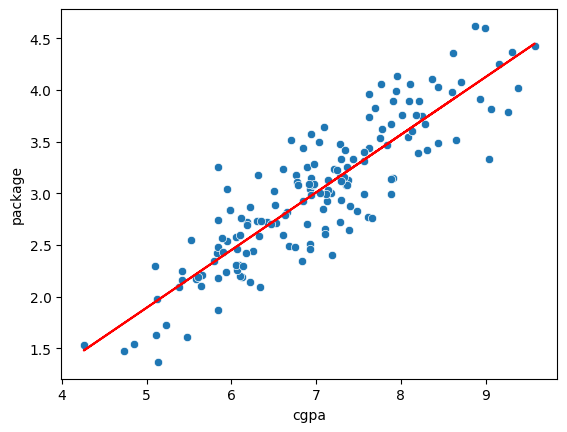

In [24]:
sns.scatterplot(x = x_train , y= y_train)

plt.plot(x_train.values.reshape(-1, 1), lr.predict(x_train.values.reshape(-1 , 1)), color='red')

plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , root_mean_squared_error , r2_score
y_pred = lr.predict(x_test.values.reshape(-1 , 1))
print("MAE = " , mean_absolute_error(y_test , y_pred))

MAE =  0.2884710931878175


In [28]:
print("MSE = ", mean_squared_error(y_test, y_pred))

MSE =  0.12129235313495527


In [30]:
print("RMSE = ", np.sqrt(mean_squared_error(y_test, y_pred)))

RMSE =  0.34827051717731616


In [31]:
print("R2_Score = ", r2_score(y_test, y_pred))

R2_Score =  0.780730147510384


In [32]:
# Adjusted r2_score
r2 = r2_score(y_test, y_pred)
1-((1-r2)*(40-1))/(40-1-1)

0.7749598882343415

In [47]:
# adding new random column in dataset to see difference in adjusted r2 score and r2 score.
new_df = df.copy()
new_df['Random_value'] = np.random.rand(200)
new_df = new_df[['cgpa', 'Random_value', 'package']]
new_df

,cgpa,Random_value,package
0,6.89,0.254326,3.26
1,5.12,0.559314,1.98
2,7.82,0.559825,3.25
3,7.42,0.100868,3.67
4,6.94,0.411953,3.57
...,...,...,...
195,6.93,0.397614,2.46
196,5.89,0.996753,2.57
197,7.21,0.939784,3.24
198,7.63,0.630156,3.96


<Axes: xlabel='Random_value', ylabel='package'>

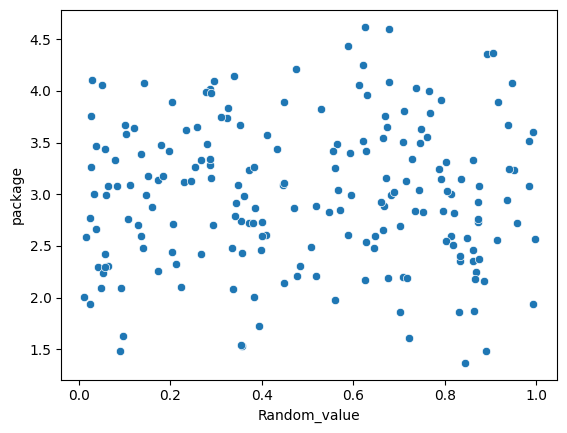

In [48]:
sns.scatterplot(x=new_df['Random_value'], y=new_df['package'])

In [49]:
x = new_df.iloc[: , 0:2]
y = new_df.iloc[: , -1]

In [50]:
x_train , x_test , y_train , y_test = train_test_split(x, y ,  test_size=0.2 , random_state=2)

In [51]:
lr = LinearRegression()

In [52]:
lr.fit(x_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
y_pred = lr.predict(x_test)

In [55]:
print('r2_score = ' , r2_score(y_test , y_pred))
r2 = r2_score(y_test, y_pred)

r2_score =  0.7781536623127081


In [56]:
# Adjusted r2 score
1-((1-r2)*(40-1))/(40-1-2)

0.7661619683836653